In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np
from sklearn.metrics import make_scorer, f1_score

import optuna

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carga del dataset

In [2]:
train_df = pd.read_csv(r'dataset/train.csv', index_col='CustomerId')
train_df

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,0
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,0
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,0
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73,0
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05,0
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38,1


In [3]:
X = train_df.drop(columns=['Exited'])
y = train_df['Exited']

In [4]:
X

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86
...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38


In [5]:
y

CustomerId
15759244    0
15725997    0
15724296    0
15636820    0
15744529    0
           ..
15628303    0
15699225    0
15612525    1
15724321    1
15578761    1
Name: Exited, Length: 8000, dtype: int64

In [6]:
test_df = pd.read_csv(r'dataset/test.csv', index_col='CustomerId')
test_df

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,,
15764618,Tseng,815.0,Spain,Female,39,6,0.00,1.0,1.0,1,85167.88
15626385,George,714.0,Spain,Female,33,10,103121.33,2.0,1.0,1,49672.01
15687413,Sunderland,619.0,Spain,Female,38,6,0.00,2.0,1.0,1,117616.29
15759067,Bromby,537.0,Germany,Female,37,7,158411.95,4.0,1.0,1,117690.58
15614049,Hu,664.0,France,Male,55,8,0.00,2.0,1.0,1,139161.64
...,...,...,...,...,...,...,...,...,...,...,...
15572956,Steen,683.0,France,Male,36,5,115350.63,NaN,NaN,1,122305.91
15714080,Goliwe,NaN,Germany,Female,40,2,NaN,2.0,1.0,0,NaN
15637366,Su,505.0,Germany,Female,25,5,114268.85,2.0,1.0,1,126728.27


# Análisis exploratorio

**Características principales**
1. Identificación del cliente
    - ```CustomerId```: ID único del cliente
    - ```Surname```: Apellido del cliente
2. Información financiera
    - ```CreditScore```: Calificación crediticia. Establece la capacidad de una persona para pagar su deuda y el riesgo que conlleva invertir con ella.
    - ```Balance```: Saldo en la cuenta bancaria
    - ```NumOfProducts```: Número de productos bancarios que utiliza
    - ```HasCrCard```: Si tiene tarjeta de crédito (0 = no, 1 = sí)
    - ```EstimatedSalary```: Salario estimado
3. Información demográfica y personal
    - ```Geography```: País de residencia
    - ```Gender```: Género (Male/Female)
    - ```Age```: Edad
    - ```Tenure```: Años como cliente del banco
    - ```IsActiveMember```: Si es un miembro activo del banco (0 = no, 1 = sí)
4. Variable objetivo
    - ```Exited```: Indicador binario de abandono del banco (0 = se queda, 1 = se va)

**Tipo de datos**
- Numéricos: ```Integer``` o ```Float``` (```CreditScore```, ```Age```, ```Balance```, ```EstimatedSalary```, etc.)
- Categóricos: ```Gender```, ```Geography```, ```HasCrCard```, ```IsActiveMember```, ```Exited```

In [7]:
cat_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']
num_cols = [col for col in X.columns if col not in cat_cols and col != 'Surname']

print(cat_cols)
print(num_cols)

['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']


In [8]:
print("\nDimensiones del dataset:")
print(X.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts().sort_index())

print("\nEstadísticas descriptivas:")
print(X.describe())


Dimensiones del dataset:
(8000, 11)

Distribución de la variable objetivo:
Exited
0    6370
1    1630
Name: count, dtype: int64

Estadísticas descriptivas:
       CreditScore          Age       Tenure        Balance  NumOfProducts  \
count  6359.000000  8000.000000  8000.000000    6385.000000    7024.000000   
mean    661.235257    38.935000     5.013875   76929.669179       1.539721   
std      95.876126    10.381389     2.888810   62292.133487       0.574125   
min     350.000000    18.000000     0.000000       0.000000       1.000000   
25%     595.000000    32.000000     3.000000       0.000000       1.000000   
50%     664.000000    37.000000     5.000000   98009.130000       2.000000   
75%     729.000000    44.000000     8.000000  127660.460000       2.000000   
max     850.000000    92.000000    10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary  
count  7625.000000     8000.000000      7168.000000  
mean      0.706623        0.5135

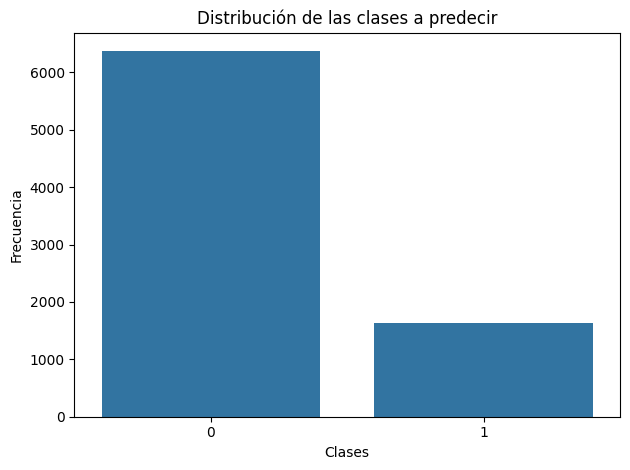

In [9]:
sns.countplot(data=train_df, x="Exited")
plt.title("Distribución de las clases a predecir")
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Detección de valores anómalos/extremos

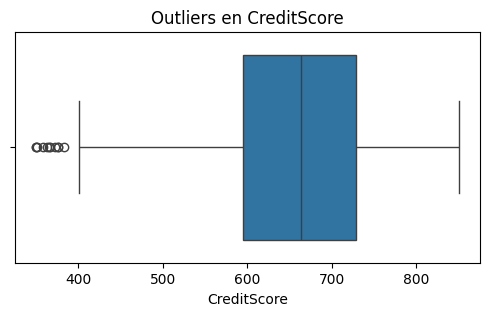

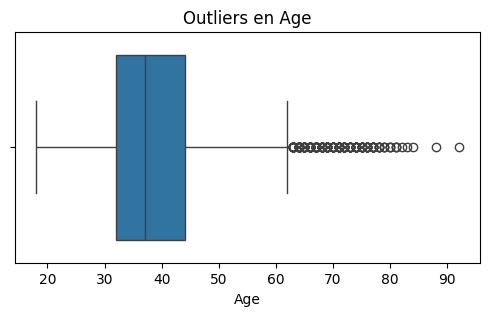

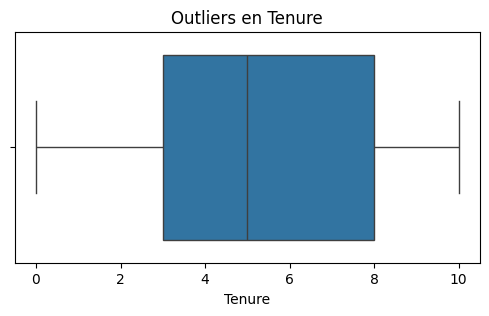

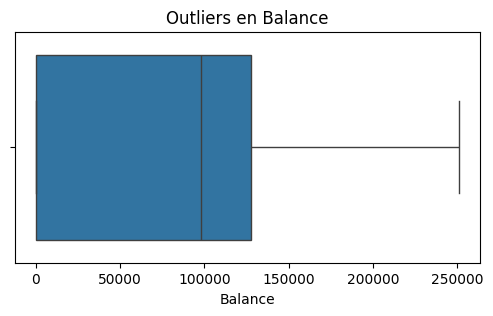

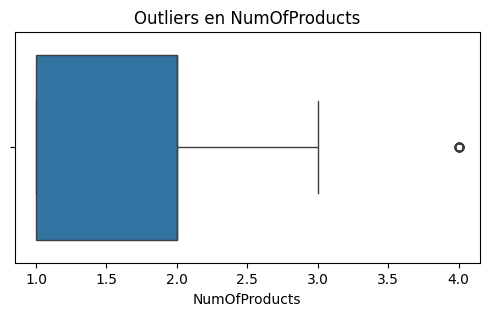

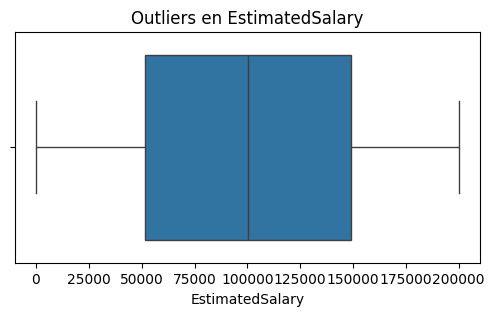

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=X[col])
    plt.title(f"Outliers en {col}")
    plt.show()

## Valores faltantes

In [11]:
print("\nValores faltantes por columna:")
print(X.isnull().sum())


Valores faltantes por columna:
Surname             409
CreditScore        1641
Geography             0
Gender                0
Age                   0
Tenure                0
Balance            1615
NumOfProducts       976
HasCrCard           375
IsActiveMember        0
EstimatedSalary     832
dtype: int64


## Correlacion

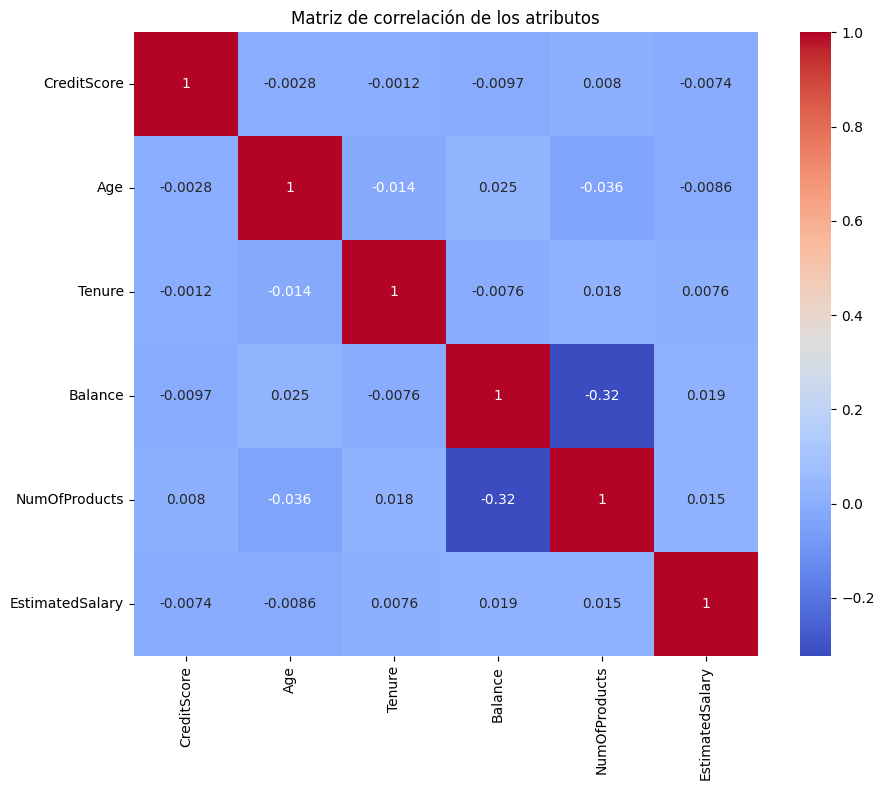

                 CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore         1.000000 -0.002823 -0.001184 -0.009667       0.007970   
Age                -0.002823  1.000000 -0.013730  0.025038      -0.035964   
Tenure             -0.001184 -0.013730  1.000000 -0.007552       0.018016   
Balance            -0.009667  0.025038 -0.007552  1.000000      -0.323886   
NumOfProducts       0.007970 -0.035964  0.018016 -0.323886       1.000000   
EstimatedSalary    -0.007368 -0.008610  0.007587  0.019494       0.014698   

                 EstimatedSalary  
CreditScore            -0.007368  
Age                    -0.008610  
Tenure                  0.007587  
Balance                 0.019494  
NumOfProducts           0.014698  
EstimatedSalary         1.000000  


In [12]:
# Correlación entre atributos
plt.figure(figsize=(10, 8))
sns.heatmap(
    X[num_cols].corr(),
    cmap="coolwarm",
    annot=True,
    square=True
)
plt.title("Matriz de correlación de los atributos")
plt.tight_layout()
plt.show()

print(X[num_cols].corr())

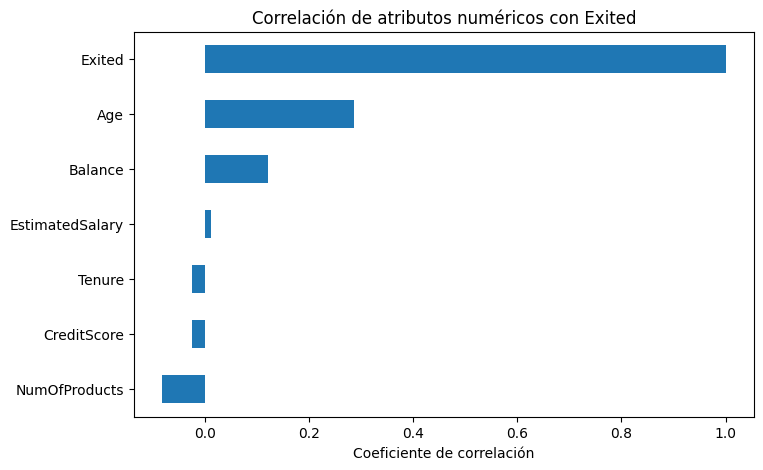

In [13]:
# Correlacion con la variable a predecir
corr_series = X[num_cols].join(y).corr()['Exited'].sort_values()

plt.figure(figsize=(8,5))
corr_series.plot(kind='barh')
plt.title('Correlación de atributos numéricos con Exited')
plt.xlabel('Coeficiente de correlación')
plt.show()

## Analisis de variables categoricas


Distribución de Gender:
Gender
Male      4384
Female    3616
Name: count, dtype: int64


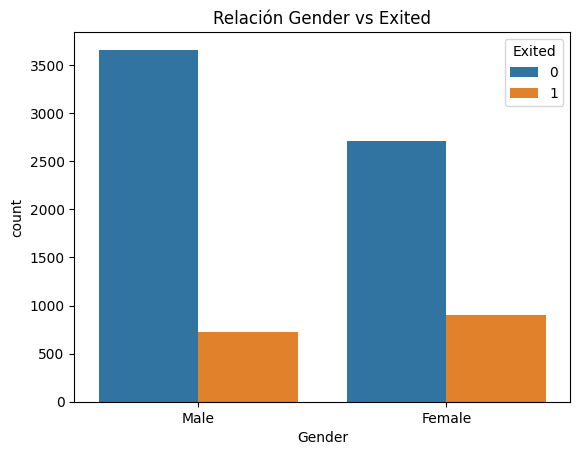


Distribución de Geography:
Geography
France     4030
Germany    1986
Spain      1984
Name: count, dtype: int64


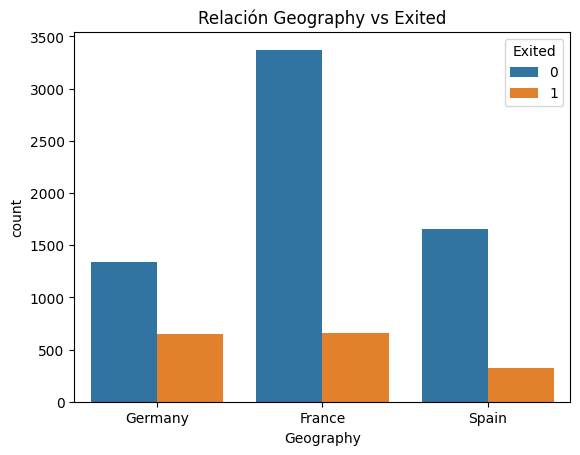


Distribución de HasCrCard:
HasCrCard
1.0    5388
0.0    2237
Name: count, dtype: int64


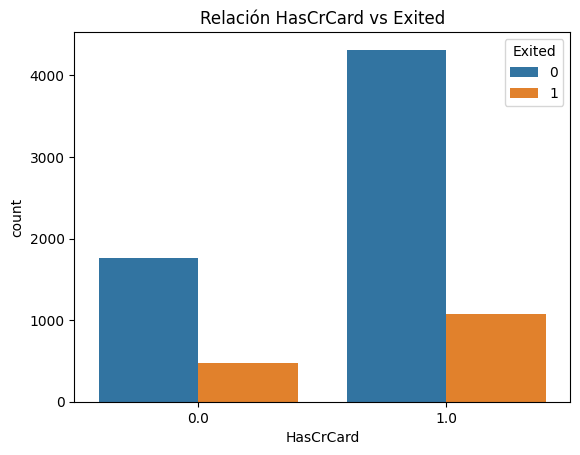


Distribución de IsActiveMember:
IsActiveMember
1    4108
0    3892
Name: count, dtype: int64


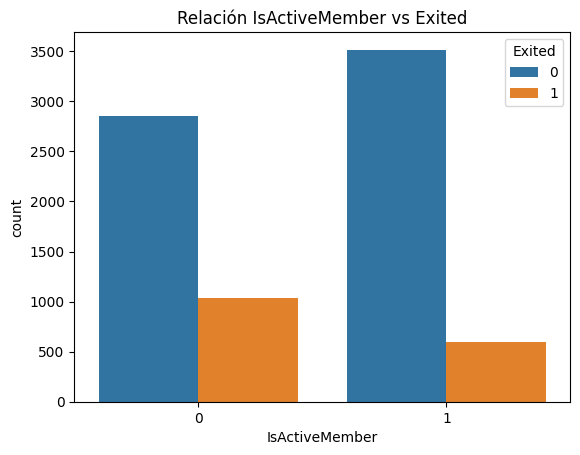

In [14]:
for col in cat_cols:
    print(f"\nDistribución de {col}:")
    print(train_df[col].value_counts())
    
    sns.countplot(data=train_df, x=col, hue='Exited')
    plt.title(f"Relación {col} vs Exited")
    plt.show()


## Creación de nuevos atributos

In [15]:
# Capacidad financiera
X['BalanceSalaryRatio'] = X['Balance'] / (X['EstimatedSalary'] + 1)

# Balance por edad
X['BalancePerAge'] = X['Balance'] / (X['Age'] + 1)

# Score crediticio del cliente relativo al balance
X['CreditScorePerBalance'] = X['CreditScore'] / (X['Balance'] + 1)

X

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,BalancePerAge,CreditScorePerBalance
CustomerId,,,,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,53.312542,2119.292000,0.007204
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,5.248207,2799.132500,0.006550
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0.995819,2851.969524,0.005710
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,1.679051,2540.235610,0.006961
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0.000000,0.000000,510.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73,0.000000,0.000000,738.000000
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05,0.000000,0.000000,757.000000
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38,NaN,NaN,NaN


# Preprocesamiento

In [16]:
# Transformaciones de variables numericas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformaciones de variables categoricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Modelos

In [112]:
models = {
    # "Logistic Regression": LogisticRegression(max_iter=200),
    # "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(),
    # "Gradient Boosting": GradientBoostingClassifier(),
    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    # "SVM (RBF)": SVC(kernel='rbf', probability=True),
    # "KNN": KNeighborsClassifier(),
    # "Naive Bayes": GaussianNB(),
    # "LightGBM": LGBMClassifier()
}

In [110]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class CatBoostSklearn(CatBoostClassifier, BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def fit(self, X, y):
        super().fit(X, y)
        return self

# models["CatBoost"] = CatBoostSklearn(verbose=False, depth=8, iterations=500, learning_rate=0.05)
# models["CatBoost"] = CatBoostSklearn(verbose=False)


In [113]:
from sklearn.neural_network import MLPClassifier

models["MLP"] = MLPClassifier(
    # hidden_layer_sizes=(100, 50),
    # activation="relu",
    # solver="adam",
    # max_iter=500,
    random_state=42
)

# Entrenamiento

In [91]:
f1_scorer = make_scorer(f1_score, greater_is_better=True)

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf', model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring=f1_scorer, n_jobs=-1)
        
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: F1 = 0.3123 ± 0.0184
Decision Tree: F1 = 0.4809 ± 0.0121
Random Forest: F1 = 0.5468 ± 0.0074
Gradient Boosting: F1 = 0.5593 ± 0.0198


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:44:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:44:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:44:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:44:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/hom

XGBoost: F1 = 0.5509 ± 0.0220
SVM (RBF): F1 = 0.4952 ± 0.0198
KNN: F1 = 0.4876 ± 0.0143
Naive Bayes: F1 = 0.4358 ± 0.0120
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 852
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 853
[LightGBM] [Info] Numb

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature nam

LightGBM: F1 = 0.5683 ± 0.0183
CatBoost: F1 = 0.5705 ± 0.0202


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  war

MLP: F1 = 0.5608 ± 0.0303


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Visualización de resultados

In [92]:
df_results = pd.DataFrame(results, index=["F1_mean", "F1_std"]).T
df_results = df_results.sort_values("F1_mean", ascending=False)
df_results

,F1_mean,F1_std
CatBoost,0.570511,0.020190
LightGBM,0.568274,0.018343
MLP,0.560821,0.030271
Gradient Boosting,0.559313,0.019807
XGBoost,0.550900,0.022033
Random Forest,0.546777,0.007377
SVM (RBF),0.495189,0.019833
KNN,0.487578,0.014277
Decision Tree,0.480946,0.012081
Naive Bayes,0.435750,0.011971


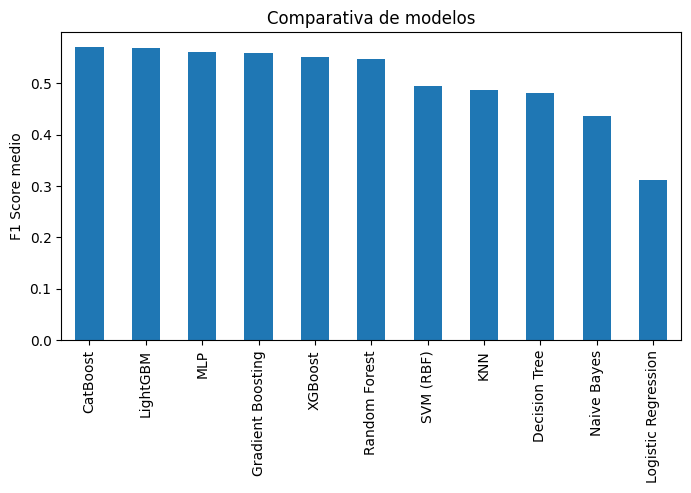

In [93]:
df_results['F1_mean'].plot(kind='bar', figsize=(8,4))
plt.ylabel('F1 Score medio')
plt.title('Comparativa de modelos')
plt.show()


# Predecir

In [94]:
# Ejemplo: seleccionar el modelo con mayor F1
best_model_name = max(results, key=lambda k: results[k])
print("Mejor modelo según F1:", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', best_model)
])

best_pipeline.fit(X, y)

y_test_pred = best_pipeline.predict(test_df)

submission = pd.DataFrame({
    "CustomerId": test_df.index,  # si CustomerId está como índice
    "Exited": y_test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

Mejor modelo según F1: CatBoost


,CustomerId,Exited
0,15764618,0
1,15626385,0
2,15687413,0
3,15759067,1
4,15614049,0


# Optimización de hiperparámetros

In [108]:
def objective(trial, model_name):

    if model_name == "Logistic Regression":
        model = LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 1e2, log=True),
            max_iter=500
        )

    elif model_name == "Decision Tree":
        model = DecisionTreeClassifier(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10)
        )

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 3, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            n_jobs=-1
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 6)
        )

    elif model_name == "XGBoost":
        model = XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 200, 600),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            eval_metric="logloss",
            use_label_encoder=False
        )

    elif model_name == "LightGBM":
        model = LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 200, 600),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            num_leaves=trial.suggest_int("num_leaves", 20, 100),
            max_depth=trial.suggest_int("max_depth", -1, 15)
        )

    elif model_name == "SVM (RBF)":
        model = SVC(
            C=trial.suggest_float("C", 1e-3, 1e2, log=True),
            gamma=trial.suggest_float("gamma", 1e-4, 1e-1, log=True),
            probability=True
        )

    elif model_name == "KNN":
        model = KNeighborsClassifier(
            n_neighbors=trial.suggest_int("n_neighbors", 3, 30),
            weights=trial.suggest_categorical("weights", ["uniform", "distance"])
        )

    elif model_name == "Naive Bayes":
        model = GaussianNB(
            var_smoothing=trial.suggest_float("var_smoothing", 1e-12, 1e-7, log=True)
        )

    elif model_name == "MLP":
        model = MLPClassifier(
            hidden_layer_sizes=trial.suggest_categorical(
                "hidden_layer_sizes", [(50,), (100,), (100, 50)]
            ),
            alpha=trial.suggest_float("alpha", 1e-5, 1e-2, log=True),
            learning_rate_init=trial.suggest_float(
                "learning_rate_init", 1e-4, 1e-2, log=True
            ),
            max_iter=500,
            random_state=42
        )

    elif model_name == "CatBoost":
        model = CatBoostSklearn(
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            iterations=trial.suggest_int("iterations", 200, 600),
            verbose=False
        )

    else:
        raise ValueError(f"Model {model_name} not supported")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", model)
    ])

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring=f1_scorer,
        n_jobs=-1
    )

    return scores.mean()

In [114]:
studies = {}
results = {}

for model_name in models.keys():
    print(f"\nOptimizando {model_name}")

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, model_name), n_trials=30)

    studies[model_name] = study
    results[model_name] = study.best_value

    print(f"Mejor F1: {study.best_value:.4f}")


[I 2026-01-08 18:01:23,717] A new study created in memory with name: no-name-e17cf371-2af9-480e-85fc-ce209e0ae48f



Optimizando MLP


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  warnings.warn(message)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWa

KeyboardInterrupt: 

In [ ]:
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: F1 = {score:.4f}")

In [ ]:
best_model_name = max(results, key=results.get)
best_params = studies[best_model_name].best_params

print("Mejor modelo:", best_model_name)
print("Mejores parámetros:", best_params)
